In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import src

For the simulation of wind power output, the Ornstein-Uhlenbeck (OU) process was chosen since we assume we have a goal for power generation for wind energy that should revolve around a $P_w$ since if we produce more, there could be mechanical stress in the wind turbine (though we can endure some "overproduction"), and we want it to not bee to low.

OU Process: $$dx_t = \theta(\mu - x_t)dt + \sigma dW_t$$

- $\theta$: mean reversion speed (how fast it goes back to "normal" operation)
- $\mu$: long term mean of wind speed
- $\sigma$: volatility 

For wind power generation, the basic equation is the follow:
$\frac{1}{2}\rho A v^3 \eta _{total}$

- v: speed of wind at hub height
- $\rho$: air density
- $\eta _{total}$: Total efficiency of wind turbine ($C_p \times \eta _{turbine}$ ) 
- A: Sweep area of turbine blades


Assumptions:

- Offshore wind farm in north-west Germany (Based off Sylt's airport EDXW)
- since data is collected onshore, we will assume an offshore mean velocity 25%* higher and maybe 90% of the standard deviation due to less obstruction at the sea
- Turbine: Vestas V236-15.0 MW with some assumptions
- Blade size: 115,5m (sweep area considers radius = 118m)
- Air density: 1,225 kg/m^3
- Total wind turbine efficiency: 40%
- No energy production for: 30m/s < $v$ < 3m/s

*This will be assumed to be the velocity at Hub's altitude for simplification

In [3]:
wind_speed = src.get_wind_speed_profile()

count    16967.000000
mean         6.062830
std          2.678180
min          0.000000
25%          4.112768
50%          6.169152
75%          7.711440
max         18.507456
Name: wind_speed[m/s], dtype: float64


In [4]:
wind_speed["wind_speed[m/s]"].describe()

count    16967.000000
mean         6.062830
std          2.678180
min          0.000000
25%          4.112768
50%          6.169152
75%          7.711440
max         18.507456
Name: wind_speed[m/s], dtype: float64

In [5]:
sigma = wind_speed["wind_speed[m/s]"].std() * 0.7
speed_mean = wind_speed["wind_speed[m/s]"].mean() * 1.25
dt = 0.5 # 30 min (in this case, 1/2 h)
T = 24 * 30 * 3 #roughly 3 months of simulation (4320 data points)
theta = 0.04

In [6]:
time, x = src.simulate_ou_process(9.2, theta, speed_mean, sigma, T, dt)
y = src.wind_energy_generation_vec(x) / (3600 * 1000)

<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_20896\366140778.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.axhline(y=10, color='r', linestyle='--', label='Long-term Mean ($\mu$)')


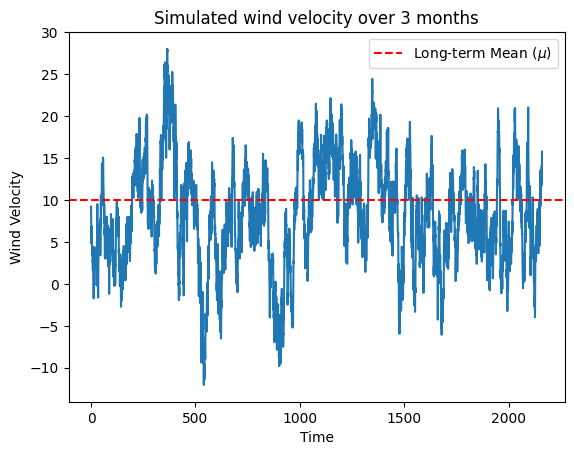

In [7]:
import matplotlib.pyplot as plt

plt.plot(time, x)
plt.axhline(y=10, color='r', linestyle='--', label='Long-term Mean ($\mu$)')
plt.title("Simulated wind velocity over 3 months")
plt.xlabel("Time"); plt.ylabel("Wind Velocity")
plt.legend(); plt.show()

<Axes: xlabel='valid'>

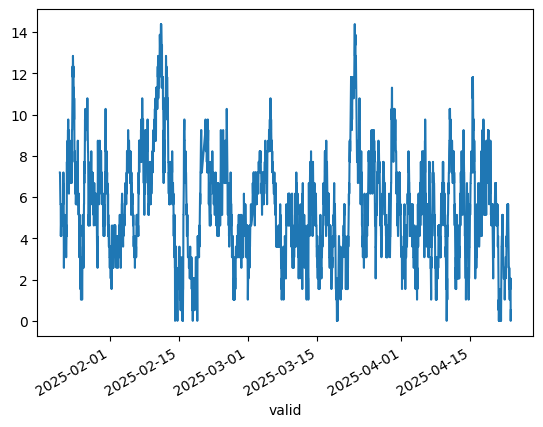

In [8]:
wind_speed["wind_speed[m/s]"].iloc[1000:5320].plot()

C:\Users\Vinicius\AppData\Local\Temp\ipykernel_20896\2539919446.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.show()


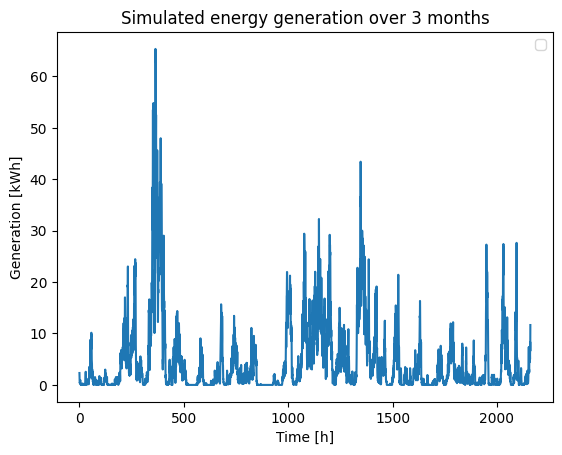

In [9]:
plt.plot(time, y)
plt.title("Simulated energy generation over 3 months")
plt.xlabel("Time [h]"); plt.ylabel("Generation [kWh]")
plt.legend(); plt.show()